# 04 — Avaliação e Interpretação

Aqui a análise deixa de ser técnica e passa a ser de negócio. Os modelos treinados no notebook 03
são avaliados no **conjunto de teste**, que nenhum modelo viu durante o treino ou a validação
cruzada. Depois vêm a interpretação das variáveis e as implicações para a concessão de crédito.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

sys.path.insert(0, str(Path("..").resolve()))
from src import config
assert config.RANDOM_STATE == RANDOM_STATE

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")
config.FIGURES.mkdir(parents=True, exist_ok=True)

In [2]:
import joblib
from sklearn.dummy import DummyClassifier

from src.data import load_processed
from src.evaluation import bootstrap_ci, comparison_table, recall_at_top, score
from src.models import NOMES
from src.preprocessing import split

df = load_processed(config.PROCESSED_FILE)
X_train, X_test, y_train, y_test = split(df)
# Carrega apenas o artefato gerado localmente pelo notebook 03 (joblib usa pickle).
modelos = joblib.load(config.MODELS / "modelos.joblib")
probs = {nome: m.predict_proba(X_test)[:, 1] for nome, m in modelos.items()}
print("Teste:", X_test.shape, "| maus pagadores no teste:", int(y_test.sum()))

Teste: (7295, 20) | maus pagadores no teste: 124


## 1. Métricas no conjunto de teste

In [3]:
LIMIAR = 0.5
resultados = {NOMES[n]: score(y_test, (p >= LIMIAR).astype(int), p) for n, p in probs.items()}

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
resultados["Baseline (sempre 'bom')"] = score(y_test, dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1])

tabela = comparison_table(resultados, name="metricas_teste", sort_by="roc_auc")

# O modelo principal foi escolhido na validação cruzada (notebook 03); o teste só confirma.
melhor = pd.read_csv(config.METRICS / "validacao_cruzada.csv", index_col="modelo").index[0]
melhor_chave = next(k for k, v in NOMES.items() if v == melhor)
print("Modelo principal (melhor ROC-AUC na validação cruzada):", melhor)
tabela

Modelo principal (melhor ROC-AUC na validação cruzada): XGBoost


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
modelo,,,,,,
XGBoost,0.8355,0.6905,0.0554,0.5403,0.1004,0.7965
Regressão Logística,0.7740,0.7146,0.0480,0.6532,0.0895,0.7880
Random Forest,0.9069,0.6238,0.0644,0.3306,0.1078,0.7497
Árvore de Decisão,0.6458,0.6772,0.0334,0.7097,0.0638,0.7448
Baseline (sempre 'bom'),0.9830,0.5000,0.0000,0.0000,0.0000,0.5000


**Leitura:**

- **O XGBoost confirma no teste o que a validação cruzada indicou:** tem o maior ROC-AUC
  (**0,797**, praticamente igual ao 0,796 da validação, sem sinal de overfitting). No corte de 0,5,
  ele identifica **54,0% dos maus pagadores** (recall).
- **A Regressão Logística fica logo atrás (0,788)** e tem a maior acurácia balanceada (0,715): ela
  encontra mais maus pagadores (65,3%), mas gera mais alarmes falsos.
- **O baseline tem a maior acurácia de todos (98,30%) e é inútil:** não encontra nenhum mau
  pagador (recall 0). É a prova de que acurácia não serve aqui.
- **O Random Forest tem acurácia de 90,7% e o maior F1 (0,108),** mas encontra só 33,1% dos maus
  pagadores.
- **A precisão é baixa para todos (3% a 6%):** de cada 100 clientes marcados como risco, só de 3 a
  6 realmente viram maus pagadores. Com uma classe de 1,7%, isso é esperado, e a seção 5 mostra
  como transformar esse resultado em ganho prático.

### Margem de erro das métricas

O teste tem poucos maus pagadores, então cada métrica oscila bastante de uma amostra para outra. O
bootstrap reamostra o teste 1.000 vezes e mostra o intervalo onde a métrica ficou em 95% das vezes.

In [4]:
intervalos = pd.concat({NOMES[n]: bootstrap_ci(y_test, p, LIMIAR, random_state=RANDOM_STATE)
                        for n, p in probs.items()})
intervalos.to_csv(config.METRICS / "intervalos_bootstrap.csv")
intervalos.unstack().round(3)

ic95_inferior                  ic95_superior         \
                          roc_auc recall precision       roc_auc recall   
Regressão Logística        0.7440 0.5690    0.0380        0.8310 0.7360   
Árvore de Decisão          0.6980 0.6300    0.0270        0.7890 0.7910   
Random Forest              0.7090 0.2520    0.0470        0.7910 0.4110   
XGBoost                    0.7570 0.4550    0.0430        0.8310 0.6260   

                               
                    precision  
Regressão Logística    0.0590  
Árvore de Decisão      0.0400  
Random Forest          0.0850  
XGBoost                0.0680

**Leitura:** com 124 maus pagadores no teste, as métricas têm margem de erro grande:

- **ROC-AUC do XGBoost: entre 0,757 e 0,831.** O da Regressão Logística fica entre 0,744 e 0,831.
  Os intervalos se sobrepõem quase inteiros, então **no teste os dois são estatisticamente
  equivalentes**, como já indicava a validação cruzada.
- **Recall do XGBoost: entre 45,5% e 62,6%.** Em uma nova amostra de clientes, o modelo pode
  encontrar de menos da metade a quase dois terços dos maus pagadores no corte de 0,5.
- Random Forest e Árvore ficam abaixo, mas também com intervalos largos.

A conclusão prática é que XGBoost e Regressão Logística são as duas opções viáveis. A escolha
entre elas pode levar em conta a interpretabilidade, não só a métrica.

## 2. Justificativa das métricas

**Por que estas métricas e não a acurácia:** com 98,31% de bons pagadores, a acurácia premia quem
ignora o problema. As métricas escolhidas respondem às perguntas de negócio:

| Métrica | Pergunta que responde |
|---|---|
| **ROC-AUC** (principal) | o modelo coloca os maus pagadores acima dos bons no ranking de risco? Não depende do corte escolhido |
| **Recall** | dos maus pagadores reais, quantos o modelo encontrou? |
| **Precisão** | dos clientes marcados como risco, quantos eram mesmo maus pagadores? |
| **F1** | equilíbrio entre recall e precisão |
| **Acurácia balanceada** | acerto médio nas duas classes, sem deixar a classe maior dominar |

**Qual erro custa mais caro:**

- **Falso negativo:** aprovar um mau pagador gera perda de crédito, porque o valor emprestado pode
  não voltar.
- **Falso positivo:** recusar ou mandar para análise um bom pagador custa a margem de um cliente
  perdido ou o tempo de um analista.

Em crédito, o falso negativo costuma ser bem mais caro. Por isso **recall e ROC-AUC têm prioridade
sobre a precisão**. Mesmo assim, a precisão baixa mostra que o modelo não deve recusar pedidos
sozinho.

## 3. Matriz de confusão

Regressão Logística  VN= 5565  FP= 1606  FN= 43  VP= 81
Árvore de Decisão    VN= 4623  FP= 2548  FN= 36  VP= 88
Random Forest        VN= 6575  FP=  596  FN= 83  VP= 41
XGBoost              VN= 6028  FP= 1143  FN= 57  VP= 67


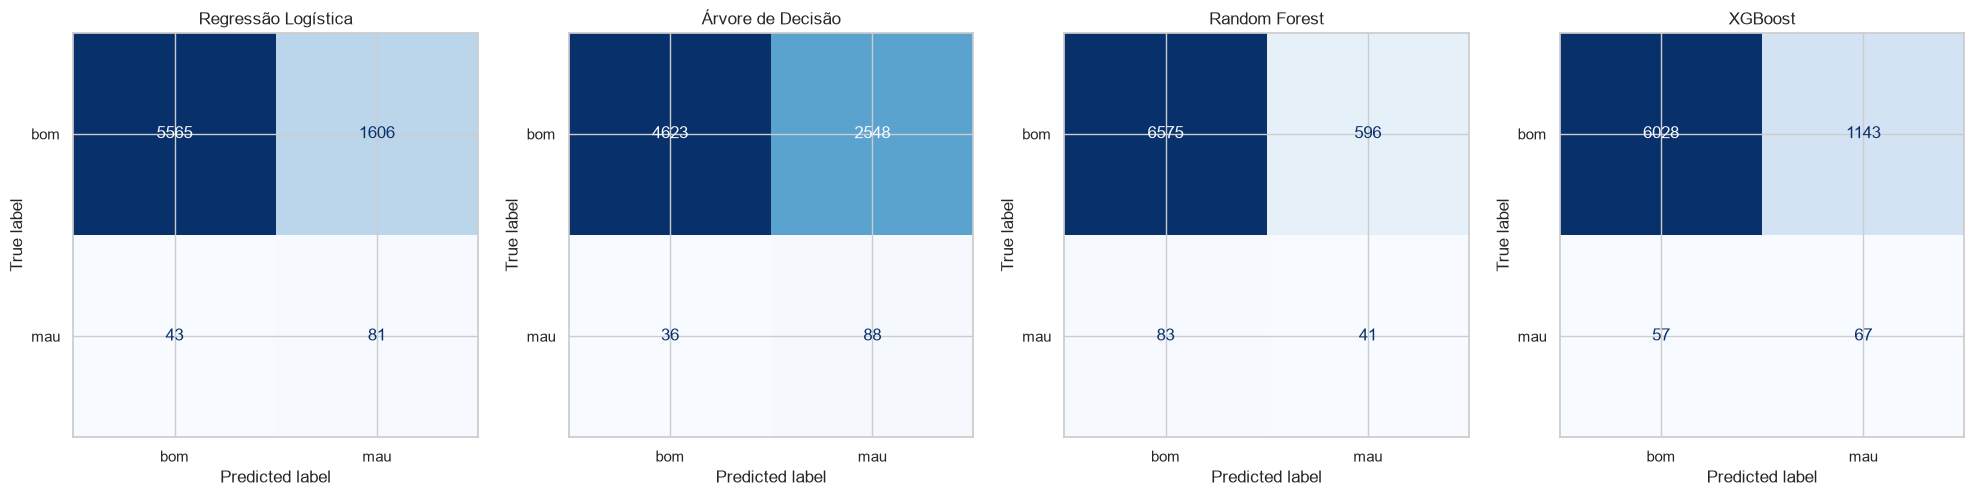

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, eixos = plt.subplots(1, 4, figsize=(20, 4.8))
for eixo, (nome, p) in zip(eixos, probs.items()):
    m = confusion_matrix(y_test, (p >= LIMIAR).astype(int))
    ConfusionMatrixDisplay(m, display_labels=["bom", "mau"]).plot(ax=eixo, cmap="Blues", colorbar=False, values_format="d")
    eixo.set_title(NOMES[nome])
    print(f"{NOMES[nome]:20s} VN={m[0,0]:5d}  FP={m[0,1]:5d}  FN={m[1,0]:3d}  VP={m[1,1]:3d}")
plt.tight_layout()
plt.savefig(config.FIGURES / "04_matrizes_confusao.png", dpi=120)
plt.show()

**Leitura (XGBoost, corte de 0,5):** dos 124 maus pagadores do teste, o modelo **identifica 67 e
deixa passar 57**. Em troca, marca como risco **1.143 bons pagadores** (15,9% dos 7.171 bons). As
alternativas mostram o trade-off:

- **Regressão Logística:** pega 81 maus pagadores, mas gera 1.606 alarmes falsos.
- **Random Forest:** gera só 596 alarmes falsos, mas deixa passar 83 dos 124 maus pagadores.
- **Árvore de Decisão:** pega 88, mas com 2.548 alarmes falsos.

Nenhum modelo elimina os dois erros ao mesmo tempo. A escolha do corte (hoje 0,5) é uma decisão de
negócio: depende de quanto custa um calote comparado a um cliente bom perdido.

## 4. Curvas ROC e precisão × recall

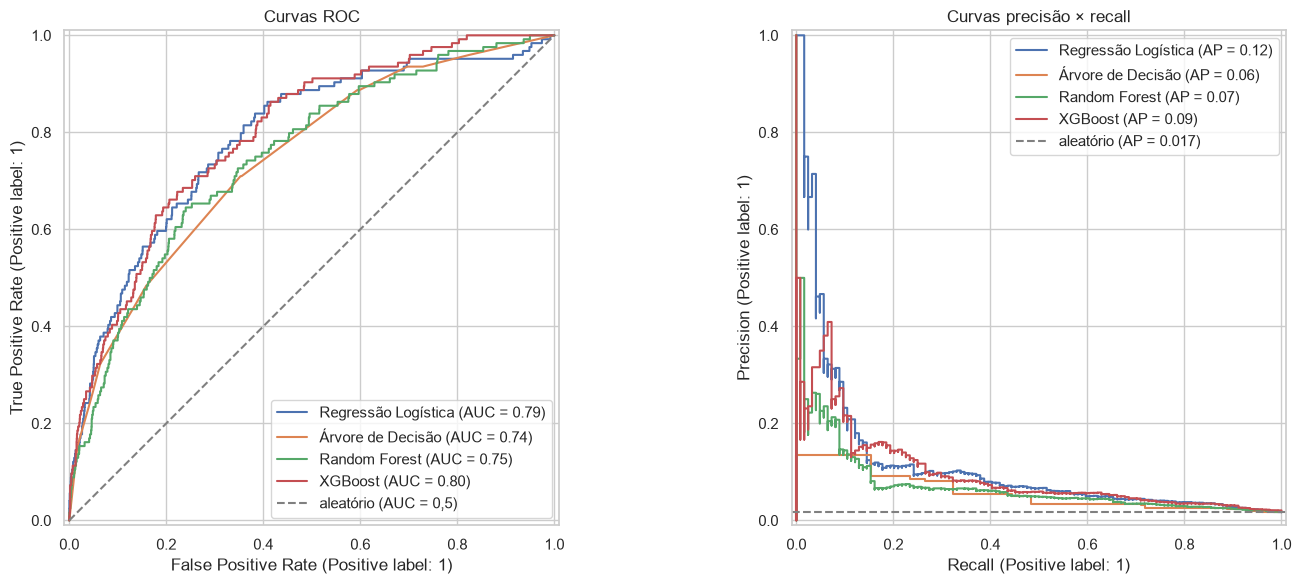

In [6]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, eixos = plt.subplots(1, 2, figsize=(15, 6))
for nome, p in probs.items():
    RocCurveDisplay.from_predictions(y_test, p, name=NOMES[nome], ax=eixos[0])
    PrecisionRecallDisplay.from_predictions(y_test, p, name=NOMES[nome], ax=eixos[1])
eixos[0].plot([0, 1], [0, 1], "--", color="gray", label="aleatório (AUC = 0,5)")
eixos[0].set_title("Curvas ROC")
eixos[0].legend(loc="lower right")
eixos[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"aleatório (AP = {y_test.mean():.3f})")
eixos[1].set_title("Curvas precisão × recall")
eixos[1].legend(loc="upper right")
plt.tight_layout()
plt.savefig(config.FIGURES / "04_curvas_roc_pr.png", dpi=120)
plt.show()

**Leitura:**

- **Curvas ROC:** as curvas do XGBoost (AUC 0,80) e da Regressão Logística (0,79) andam juntas e
  se cruzam várias vezes, acima das do Random Forest (0,75) e da Árvore (0,74) em quase toda a faixa.
- **Curvas de precisão × recall:** todas ficam acima da linha do aleatório (1,7%), mas caem rápido
  quando se exige recall alto. É o retrato do desbalanceamento: encontrar quase todos os maus
  pagadores exige aceitar muitos alarmes falsos.
- **No topo do ranking, a Regressão Logística é a melhor:** ela tem a maior average precision
  (0,12 contra 0,09 do XGBoost), porque os primeiros clientes que ela aponta como risco têm mais
  chance de ser maus pagadores de fato (recall abaixo de 0,1). A partir de recall de cerca de 0,15,
  as duas ficam parecidas.
- **Conclusão:** para revisar uma lista muito curta de casos, a Regressão Logística é melhor. Para
  uma fila de análise de tamanho realista (seção 5), o XGBoost tem leve vantagem.

## 5. Uso como ferramenta de priorização

Em vez de aprovar ou recusar pelo corte de 0,5, uma instituição pode **ordenar** os pedidos pela
probabilidade de mau pagamento e mandar para a análise manual só os mais arriscados. A tabela
mostra, para o melhor modelo, que fração dos maus pagadores reais cai dentro de cada fatia revisada.

In [7]:
fatias = [0.05, 0.10, 0.20, 0.30]
captura = pd.DataFrame({
    NOMES[n]: [recall_at_top(y_test, p, f) for f in fatias] for n, p in probs.items()
}, index=[f"top {int(f*100)}% mais arriscados" for f in fatias])
captura["Aleatório"] = fatias
captura.to_csv(config.METRICS / "captura_por_fatia.csv")
(captura * 100).round(1)

,Regressão Logística,Árvore de Decisão,Random Forest,XGBoost,Aleatório
top 5% mais arriscados,28.2000,25.0000,21.0000,27.4000,5.0000
top 10% mais arriscados,42.7000,35.5000,37.1000,40.3000,10.0000
top 20% mais arriscados,59.7000,49.2000,54.0000,63.7000,20.0000
top 30% mais arriscados,73.4000,53.2000,66.9000,72.6000,30.0000


**Leitura, e o principal resultado prático:** ordenando os pedidos pelo risco estimado pelo
XGBoost, quem revisar só os **20% mais arriscados encontra 63,7% de todos os maus pagadores**. Uma
escolha aleatória da mesma quantidade encontraria 20%, ou seja, o modelo é **3,2 vezes mais
eficiente que o acaso**. Revisando os 10% mais arriscados, já são **40,3%**, quatro vezes o acaso.

A Regressão Logística chega perto (59,7% no top 20%) e é um pouco melhor nas pontas (top 5% e top
30%). Na prática, a equipe de análise de crédito pode concentrar a análise manual em uma fração
pequena dos pedidos e ainda assim encontrar a maioria dos casos problemáticos.

## 6. E se o solicitante não tiver histórico de crédito?

As variáveis `meses_observados`, `meses_quitado` e `meses_sem_emprestimo` vêm do histórico de
crédito, que **não existe para um solicitante novo**: o edital fala em prever a aprovação "com base
em informações pessoais e financeiras dos solicitantes". Para medir quanto do desempenho depende do
histórico, treinamos os quatro modelos de novo (mesmo split por pessoa, mesmos hiperparâmetros)
usando **só os dados cadastrais**.

In [8]:
from sklearn.metrics import roc_auc_score

from src.models import get_models

colunas_historico = ["meses_observados", "meses_quitado", "meses_sem_emprestimo"]
X_train_cad = X_train.drop(columns=colunas_historico)
X_test_cad = X_test.drop(columns=colunas_historico)

cenarios = {}
for nome, modelo in get_models(X_train_cad, y_train).items():
    p_cad = modelo.fit(X_train_cad, y_train).predict_proba(X_test_cad)[:, 1]
    cenarios[NOMES[nome]] = {"roc_auc_cadastro_e_historico": roc_auc_score(y_test, probs[nome]),
                             "roc_auc_so_cadastro": roc_auc_score(y_test, p_cad),
                             "captura_top_20%_cadastro_e_historico": recall_at_top(y_test, probs[nome], 0.2),
                             "captura_top_20%_so_cadastro": recall_at_top(y_test, p_cad, 0.2)}
cenarios = pd.DataFrame(cenarios).T.round(4)
cenarios.index.name = "modelo"
cenarios.to_csv(config.METRICS / "cenario_so_cadastro.csv")
cenarios

,roc_auc_cadastro_e_historico,roc_auc_so_cadastro,captura_top_20%_cadastro_e_historico,captura_top_20%_so_cadastro
modelo,,,,
Regressão Logística,0.7880,0.5852,0.5968,0.2823
Árvore de Decisão,0.7448,0.5536,0.4919,0.1613
Random Forest,0.7497,0.5746,0.5403,0.3065
XGBoost,0.7965,0.5921,0.6371,0.3710


**Leitura, uma limitação decisiva:** sem as três variáveis de histórico, **todos os modelos caem
para perto do aleatório**. O ROC-AUC do XGBoost cai de **0,797 para 0,592**, e a captura nos 20%
mais arriscados cai de **63,7% para 37,1%**. Os outros três modelos ficam entre 0,55 e 0,59.

Ou seja: **os dados cadastrais sozinhos quase não separam bons de maus pagadores**. Isso confirma o
que a EDA já mostrava (nenhuma correlação acima de 0,03) e significa que **o poder do modelo vem do
histórico de relacionamento com o banco**.

Na prática:

- **Clientes que já têm histórico** (renovação, aumento de limite, cartão adicional): o modelo
  completo funciona como descrito acima. É para esse público que ele serve.
- **Solicitantes totalmente novos:** os dados do formulário não bastam para prever o risco. A
  decisão precisa de fontes externas, como birôs de crédito (Serasa, SPC).

## 7. Importância das variáveis

Usamos dois métodos independentes no melhor modelo:

1. **Permutation importance**: embaralha uma coluna de cada vez no teste e mede quanto o ROC-AUC
   cai, com 10 repetições por coluna.
2. **SHAP**: calcula, para cada cliente, quanto cada variável empurrou a previsão para "mau" ou
   para "bom". O explicador é escolhido conforme o modelo (linear para a Regressão Logística,
   de árvores para os demais).

Se os dois concordam, a evidência de que o padrão é real fica mais forte.

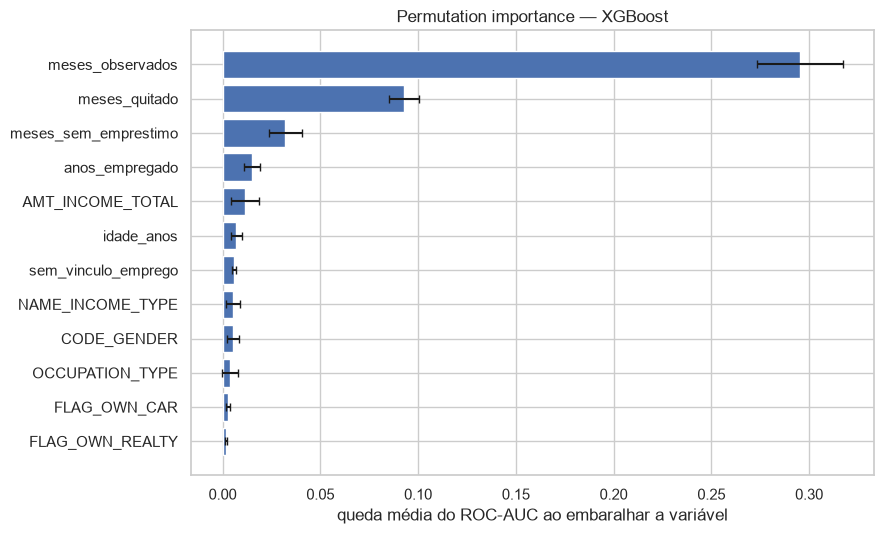

,queda_roc_auc,desvio
meses_observados,0.2954,0.0219
meses_quitado,0.0928,0.0075
meses_sem_emprestimo,0.0320,0.0084
anos_empregado,0.0149,0.0042
AMT_INCOME_TOTAL,0.0116,0.0071
idade_anos,0.0071,0.0028
sem_vinculo_emprego,0.0060,0.0011
NAME_INCOME_TYPE,0.0055,0.0036
CODE_GENDER,0.0052,0.0031
OCCUPATION_TYPE,0.0038,0.0040


In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(modelos[melhor_chave], X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importancia = (pd.DataFrame({"queda_roc_auc": perm.importances_mean, "desvio": perm.importances_std},
                            index=X_test.columns)
               .sort_values("queda_roc_auc", ascending=False))
importancia.to_csv(config.METRICS / "permutation_importance.csv")

top = importancia.head(12)[::-1]
fig, eixo = plt.subplots(figsize=(9, 5.5))
eixo.barh(top.index, top["queda_roc_auc"], xerr=top["desvio"], color="C0", capsize=3)
eixo.set_xlabel("queda média do ROC-AUC ao embaralhar a variável")
eixo.set_title(f"Permutation importance — {melhor}")
plt.tight_layout()
plt.savefig(config.FIGURES / "04_permutation_importance.png", dpi=120)
plt.show()
importancia.head(12)

C:\Users\sogys\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


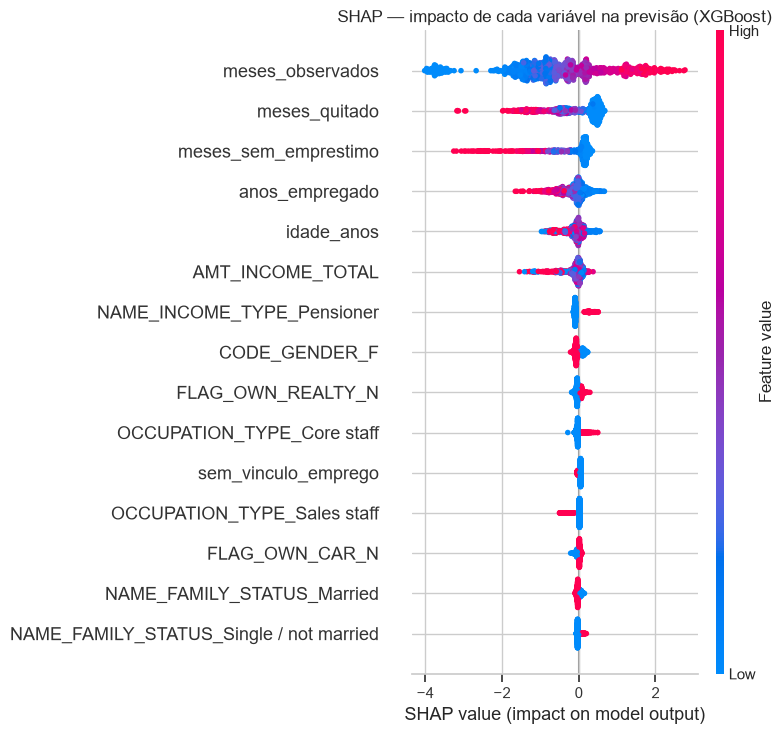

meses_observados                          1.1564
meses_quitado                             0.5518
meses_sem_emprestimo                      0.3700
anos_empregado                            0.2346
idade_anos                                0.1882
AMT_INCOME_TOTAL                          0.1474
NAME_INCOME_TYPE_Pensioner                0.1241
CODE_GENDER_F                             0.0830
FLAG_OWN_REALTY_N                         0.0565
OCCUPATION_TYPE_Core staff                0.0533
sem_vinculo_emprego                       0.0457
OCCUPATION_TYPE_Sales staff               0.0447
FLAG_OWN_CAR_N                            0.0425
NAME_FAMILY_STATUS_Married                0.0424
NAME_FAMILY_STATUS_Single / not married   0.0333
dtype: float32

In [10]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
import shap

pre = modelos[melhor_chave].named_steps["pre"]
clf = modelos[melhor_chave].named_steps["clf"]
def densa(m):
    return m.toarray() if hasattr(m, "toarray") else m

X_amostra = densa(pre.transform(X_test.sample(1000, random_state=RANDOM_STATE)))
X_fundo = densa(pre.transform(X_train.sample(500, random_state=RANDOM_STATE)))
nomes = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]

if hasattr(clf, "coef_"):  # Regressão Logística
    explicador = shap.LinearExplainer(clf, X_fundo)
else:
    explicador = shap.TreeExplainer(clf)
valores_shap = np.asarray(explicador.shap_values(X_amostra))
if valores_shap.ndim == 3:  # modelos que devolvem uma saída por classe: fica a classe "mau"
    valores_shap = valores_shap[:, :, 1]

shap.summary_plot(valores_shap, X_amostra, feature_names=nomes, max_display=15, show=False)
plt.title(f"SHAP — impacto de cada variável na previsão ({melhor})")
plt.tight_layout()
plt.savefig(config.FIGURES / "04_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

shap_global = pd.Series(np.abs(valores_shap).mean(axis=0), index=nomes).sort_values(ascending=False)
shap_global.head(15).rename("media_abs_shap").to_csv(config.METRICS / "shap_importancia.csv")
shap_global.head(15)

**Leitura:** os dois métodos **concordam** nas três variáveis mais importantes, e todas vêm do
histórico de crédito.

1. **`meses_observados`**, disparado a mais importante (embaralhá-la derruba o ROC-AUC em 0,30).
   Pelo SHAP, **mais meses de histórico aumentam o risco previsto**. Isso reflete **tempo de
   exposição**: quem é observado por 60 meses teve 60 chances de registrar um atraso, e quem é
   observado por 3 teve só 3. Não é vazamento (não usa os status de atraso), mas significa que
   parte do que o modelo aprende é "cliente antigo", não só "cliente arriscado".
2. **`meses_quitado`** (queda de 0,09): **mais meses quitando o saldo reduzem o risco**. É um sinal
   de comportamento, faz sentido no domínio.
3. **`meses_sem_emprestimo`** (queda de 0,03): **mais meses sem crédito em uso também reduzem o
   risco**, porque indicam uso moderado do crédito.

**Entre as variáveis cadastrais**, os efeitos são pequenos (quedas de 0,015 ou menos), coerentes
com o cenário "só cadastro" da seção 6:

- **Tempo de emprego e renda:** mais tempo de emprego e renda mais alta tendem a reduzir o risco.
- **Idade:** efeito pequeno e sem direção clara.
- **Aposentados** (`NAME_INCOME_TYPE_Pensioner`) aparecem com risco um pouco maior, o que é
  coerente com a taxa de 2,11% vista na EDA.

**Alerta de equidade:** `CODE_GENDER` tem peso mensurável no modelo (as mulheres aparecem com risco
menor). Usar gênero em decisões de crédito levanta questões legais e éticas. Antes de qualquer uso
real, é necessária uma auditoria de equidade (métricas de erro separadas por gênero) e a avaliação
de remover a variável.

## 8. Implicações práticas

1. **Usar o modelo para priorizar a análise, não para decidir sozinho.** Ordenar os pedidos pelo
   risco e revisar os 20% mais arriscados encontra cerca de 6 em cada 10 maus pagadores, 3 vezes
   mais que o acaso. A equipe de análise concentra esforço onde há mais risco, e os demais pedidos
   seguem o fluxo normal.
2. **Não automatizar a recusa.** Com precisão de cerca de 6%, recusar automaticamente todo cliente
   marcado como risco significaria negar crédito a cerca de 17 bons pagadores para cada mau pagador
   evitado. O custo comercial e reputacional seria alto.
3. **O modelo serve para quem já é cliente.** Com histórico, o ROC-AUC é 0,80. Só com o cadastro,
   cai para 0,59, perto do acaso. Para solicitantes novos, a decisão precisa de birôs de crédito
   externos.
4. **XGBoost e Regressão Logística são equivalentes no desempenho.** Se a área de risco ou o
   regulador exigir explicar cada decisão, a Regressão Logística entrega praticamente o mesmo
   resultado com coeficientes fáceis de auditar.
5. **O corte de decisão é uma escolha de negócio.** O corte de 0,5 usado aqui é didático. Com os
   custos reais de um calote e de um cliente perdido, dá para escolher o corte que minimiza o
   prejuízo total.
6. **Revisar o uso de gênero antes de produção.** A variável influencia a previsão e precisa de
   auditoria de equidade e validação jurídica.

## 9. Limitações

- **Alvo construído, não observado:** "mau pagador" foi definido como atraso de 60 dias ou mais em
  qualquer mês do histórico. Um corte de 30 dias, ou uma janela de tempo fixa, mudaria o problema.
  Com mais tempo, valeria testar alternativas e comparar a estabilidade do modelo.
- **Janela temporal:** as features de histórico e o alvo vêm do mesmo período observado. Em
  produção, o correto seria calcular as features com os meses *anteriores* a uma data de corte e
  medir o alvo nos meses *seguintes*. A base não tem datas absolutas, o que dificulta essa
  separação.
- **Tempo de exposição:** a variável mais importante mede em parte há quanto tempo o cliente é
  observado. Normalizar o alvo pelo tempo de observação (por exemplo, exigir um mínimo de meses de
  histórico) é um próximo passo natural.
- **Identificação de pessoas:** o `grupo_cliente` junta IDs com cadastro 100% idêntico. Se a mesma
  pessoa tiver atualizado algum dado (renda, por exemplo) entre uma conta e outra, ela aparece como
  duas pessoas. A divisão por pessoa é, portanto, um limite inferior do cuidado necessário.
- **Amostra pequena da classe rara:** 124 maus pagadores no teste. Os intervalos de confiança
  (seção 1) mostram que diferenças de 0,01 no ROC-AUC entre modelos não são significativas.
- **Precisão baixa:** cerca de 6% no corte padrão. Seria possível ajustar hiperparâmetros (busca
  em grade com validação cruzada por pessoa) e calibrar as probabilidades para melhorar o uso do
  score.
- **Equidade:** a análise por gênero e por outras variáveis sensíveis não foi feita e é
  pré-requisito para qualquer uso real.
- **Dados:** a base não traz valores de crédito, limites nem custos. Sem eles, não dá para traduzir
  os acertos e erros do modelo em valores financeiros.